# Load Dataset

In this section, we import the required library and load the e-commerce customer dataset into a Pandas DataFrame.

The dataset contains customer information, purchase details, payment methods, customer demographics, and the target variable `Churn`.

The dataset will be used throughout the project for data exploration, preprocessing, visualization, and machine learning.


In [10]:
import pandas as pd

In [11]:
import zipfile

with zipfile.ZipFile("/content/archive (3).zip", "r") as zip_ref:
    print(zip_ref.namelist())

['ecommerce_customer_data_custom_ratios.csv', 'ecommerce_customer_data_large.csv']


In [12]:
import zipfile

with zipfile.ZipFile("/content/archive (3).zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [13]:
df = pd.read_csv("/content/ecommerce_customer_data_large.csv")

In [14]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [16]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


# Data Overview

This section provides an initial understanding of the dataset structure.

We inspect the dataset dimensions, data types, column names, and statistical summary to understand the available variables before starting the data cleaning and preprocessing steps.

The dataset contains 250,000 rows and 13 columns.


In [17]:
df.shape

(250000, 13)

In [18]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


In [19]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

# Missing Values

In this section, we identify missing values in the dataset and calculate their percentages.

The analysis shows that the `Returns` column contains missing values, while the other columns do not contain missing values. The missing values in `Returns` are handled in the next step to ensure that the dataset is complete before further analysis.


In [20]:
missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100.2)
})
missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage
Returns,47382,19.0
Purchase Date,0,0.0
Product Category,0,0.0
Product Price,0,0.0
Customer ID,0,0.0
Quantity,0,0.0
Total Purchase Amount,0,0.0
Payment Method,0,0.0
Customer Age,0,0.0
Customer Name,0,0.0


In [21]:
# Use -1 to represent customers with no recorded return
df['Returns'] = df['Returns'].fillna(-1)

### Handling Missing Values

Missing values in the `Returns` column are replaced with `-1`. This value is used to represent the absence of a recorded return and allows the dataset to be used without remaining null values.


In [22]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


# Check Duplicates

Duplicate records are checked to ensure that the dataset does not contain repeated rows that could affect the analysis or machine learning results.

The dataset does not contain duplicate rows based on the duplicate check performed below.


In [23]:
duplicates = pd.DataFrame({
    "Duplicate Rows": [df.duplicated().sum()],
    "Percentage": [round(df.duplicated().mean() * 100, 2)]
})

duplicates

,Duplicate Rows,Percentage
0,0,0.0


# Convert Data

The `Purchase Date` column is converted from a text/object format into a datetime format.

Converting the date column allows us to extract useful time-related features such as the purchase year, month, day, and weekday during the feature engineering stage.


In [24]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# Feature Engineering

Feature engineering is performed to create additional variables from the existing data that may provide useful information for analysis and machine learning.

The `Purchase Date` column is transformed into separate features representing the purchase year, month, day, and weekday. After extracting these features, the original date column is removed.


In [25]:
df['Purchase Year'] = df['Purchase Date'].dt.year
df['Purchase Month'] = df['Purchase Date'].dt.month
df['Purchase Day'] = df['Purchase Date'].dt.day
df['Purchase Weekday'] = df['Purchase Date'].dt.day_name()

df = df.drop(columns=['Purchase Date'])

# Drop Unnecessary Columns

Some columns are removed because they are not required as predictive features for the machine learning models.

`Customer ID`, `Customer Age`, and `Customer Name` are excluded from the dataset at this stage.


In [26]:
drop_columns = ['Customer ID',
                'Customer Age',
                'Customer Name',
               ]
for col in drop_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Separate Numerical & Categorical Columns

The dataset is divided into numerical and categorical variables based on their data types.

Numerical columns contain quantitative values that can be directly used in numerical analysis, while categorical columns contain labels or categories that require encoding before being used by most machine learning models.


In [27]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(exclude="object").columns
print("Categorical Columns")
print(categorical_columns)
print()
print("Numerical Columns")
print(numerical_columns)

Categorical Columns
Index(['Product Category', 'Payment Method', 'Gender', 'Purchase Weekday'], dtype='object')

Numerical Columns
Index(['Product Price', 'Quantity', 'Total Purchase Amount', 'Returns', 'Age',
       'Churn', 'Purchase Year', 'Purchase Month', 'Purchase Day'],
      dtype='object')


# Numerical Features Analysis

In this step, we identify the numerical columns in the dataset and examine their values, provides descriptive statistics for the numerical variables.

Numerical features contain quantitative data that can be used for statistical analysis .

The summary includes measures such as the count, mean, standard deviation, minimum, maximum, and quartiles. These statistics help us understand the distributions and ranges of the numerical features before proceeding with further analysis.



In [28]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Product Price,250000.0,254.742724,141.738104,10.0,132.0,255.0,377.0,500.0
Quantity,250000.0,3.004936,1.414737,1.0,2.0,3.0,4.0,5.0
Total Purchase Amount,250000.0,2725.385196,1442.576095,100.0,1476.0,2725.0,3975.0,5350.0
Returns,250000.0,0.216376,0.740686,-1.0,0.0,0.0,1.0,1.0
Age,250000.0,43.798276,15.364915,18.0,30.0,44.0,57.0,70.0
Churn,250000.0,0.200520,0.400390,0.0,0.0,0.0,0.0,1.0
Purchase Year,250000.0,2021.377136,1.074712,2020.0,2020.0,2021.0,2022.0,2023.0
Purchase Month,250000.0,6.190376,3.353238,1.0,3.0,6.0,9.0,12.0
Purchase Day,250000.0,15.654804,8.806431,1.0,8.0,16.0,23.0,31.0


# Categorical Features Analysis

This section examines the frequency distribution of the categorical variables.

Categorical features contain non-numerical values such as categories or labels.

The value counts help us understand how observations are distributed across product categories, payment methods, gender, and purchase weekdays. This provides an overview of the categorical variables before encoding and modeling.


In [29]:
for col in categorical_columns:
    print("=" * 50)
    print(col)
    print("=" * 50)
    print(df[col].value_counts())
    print()

Product Category
Product Category
Electronics    62630
Clothing       62581
Home           62542
Books          62247
Name: count, dtype: int64

Payment Method
Payment Method
Credit Card    83547
PayPal         83441
Cash           83012
Name: count, dtype: int64

Gender
Gender
Male      125676
Female    124324
Name: count, dtype: int64

Purchase Weekday
Purchase Weekday
Wednesday    35973
Thursday     35889
Saturday     35845
Friday       35629
Monday       35612
Tuesday      35577
Sunday       35475
Name: count, dtype: int64



# Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers in the numerical columns.

For each feature, the first quartile (Q1), third quartile (Q3), and IQR are calculated. Values outside the lower and upper bounds are considered potential outliers.

This step helps assess whether extreme values are present and whether they require further treatment before modeling.


In [30]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("=" * 50)
    print(f"Column: {col}")
    print(f"Number of Outliers: {len(outliers)}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")

Column: Product Price
Number of Outliers: 0
Lower Bound: -235.5
Upper Bound: 744.5
Column: Quantity
Number of Outliers: 0
Lower Bound: -1.0
Upper Bound: 7.0
Column: Total Purchase Amount
Number of Outliers: 0
Lower Bound: -2272.5
Upper Bound: 7723.5
Column: Returns
Number of Outliers: 0
Lower Bound: -1.5
Upper Bound: 2.5
Column: Age
Number of Outliers: 0
Lower Bound: -10.5
Upper Bound: 97.5
Column: Churn
Number of Outliers: 50130
Lower Bound: 0.0
Upper Bound: 0.0
Column: Purchase Year
Number of Outliers: 0
Lower Bound: 2017.0
Upper Bound: 2025.0
Column: Purchase Month
Number of Outliers: 0
Lower Bound: -6.0
Upper Bound: 18.0
Column: Purchase Day
Number of Outliers: 0
Lower Bound: -14.5
Upper Bound: 45.5


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand the dataset and identify patterns, distributions, and relationships between the different variables.

In this section, we use statistical summaries and visualizations to explore the numerical and categorical features and investigate their relationship with the target variable `Churn`.


### 1. Univariate Analysis



In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
numerical_columns

Index(['Product Price', 'Quantity', 'Total Purchase Amount', 'Returns', 'Age',
       'Churn', 'Purchase Year', 'Purchase Month', 'Purchase Day'],
      dtype='object')

In [33]:
continuous_columns = [
    'Product Price',
    'Quantity',
    'Total Purchase Amount',
    'Age'
]

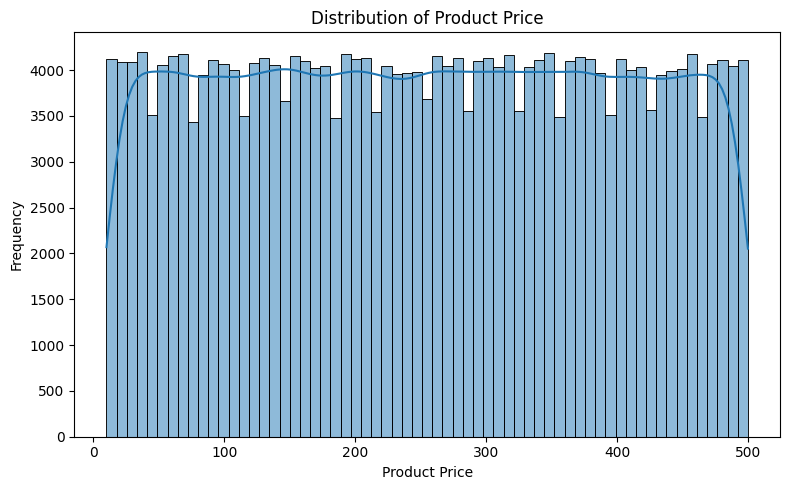

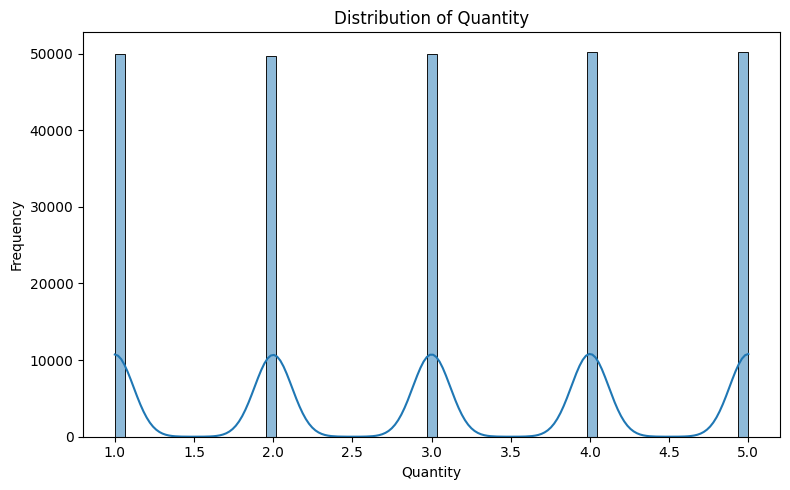

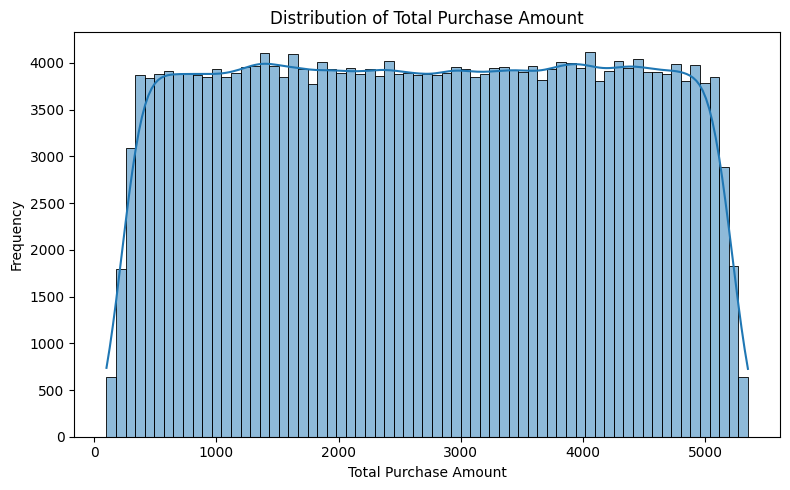

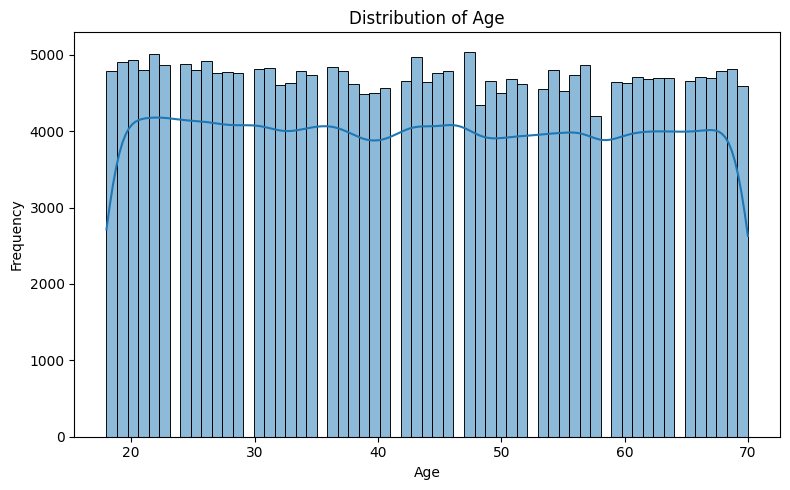

In [34]:
for col in continuous_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    print("\n" * 3)

## Distribution of Numerical Features

Boxplots are used to visualize the distribution of the numerical features and identify potential outliers.

The boxplots help us compare the spread, central tendency, and extreme values of the continuous variables.


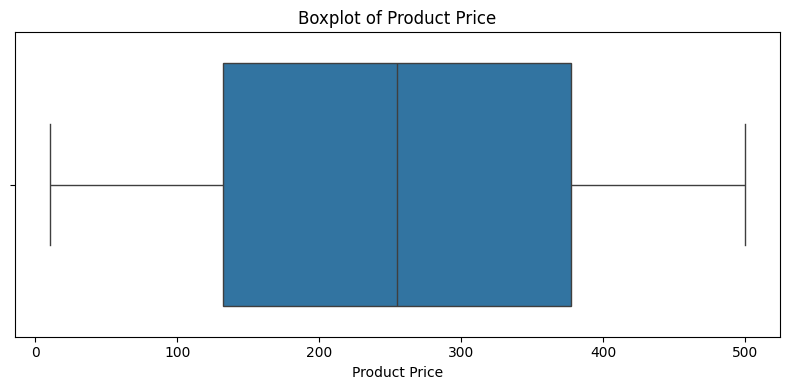

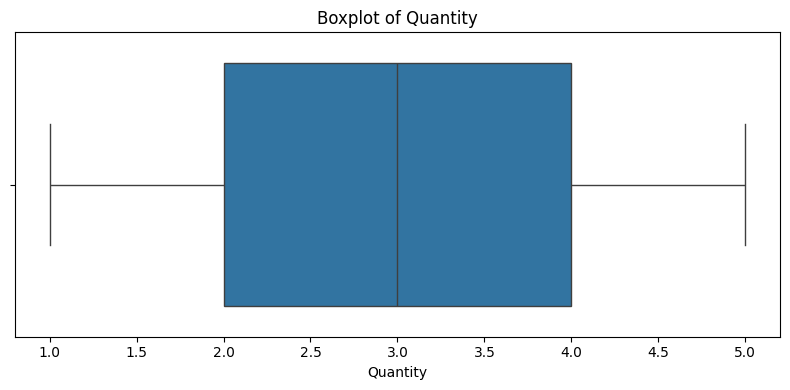

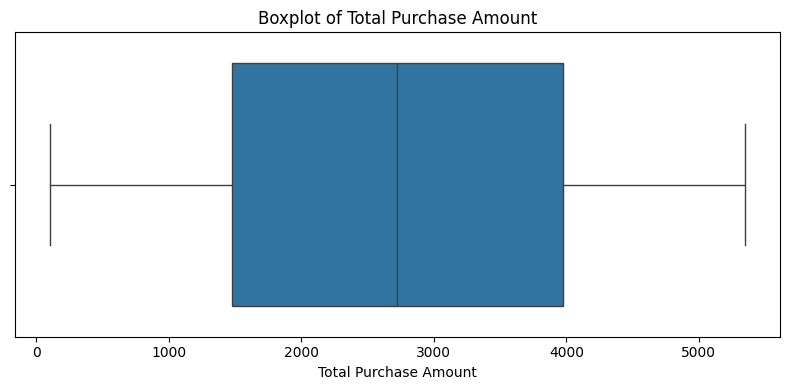

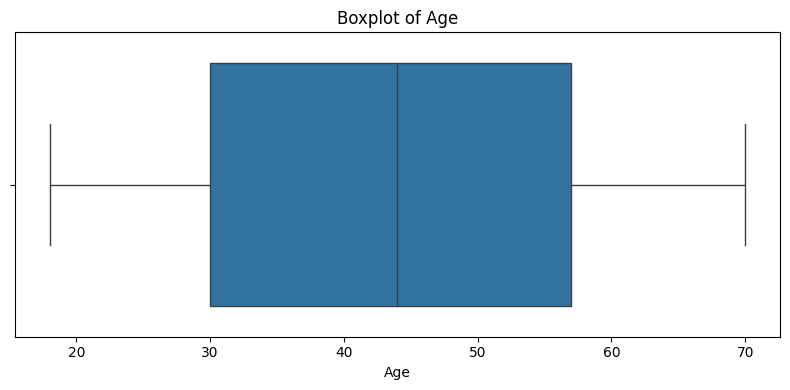

In [35]:
for col in continuous_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=col)

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

    print("\n")

In [36]:
categorical_columns

Index(['Product Category', 'Payment Method', 'Gender', 'Purchase Weekday'], dtype='object')

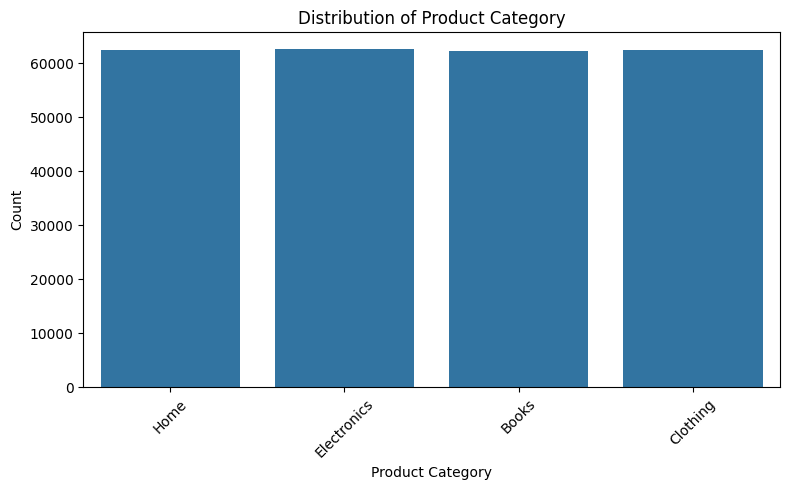

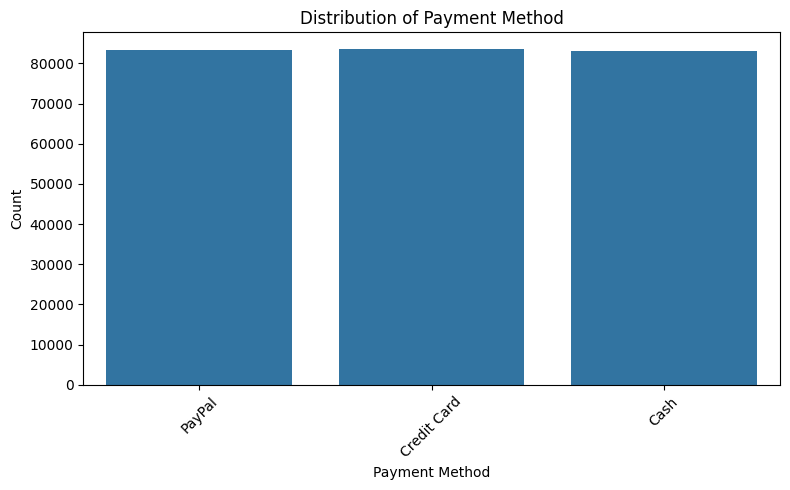

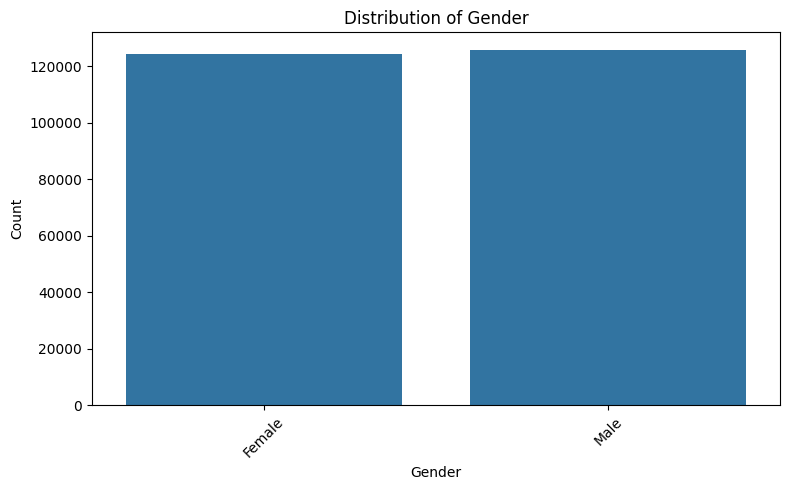

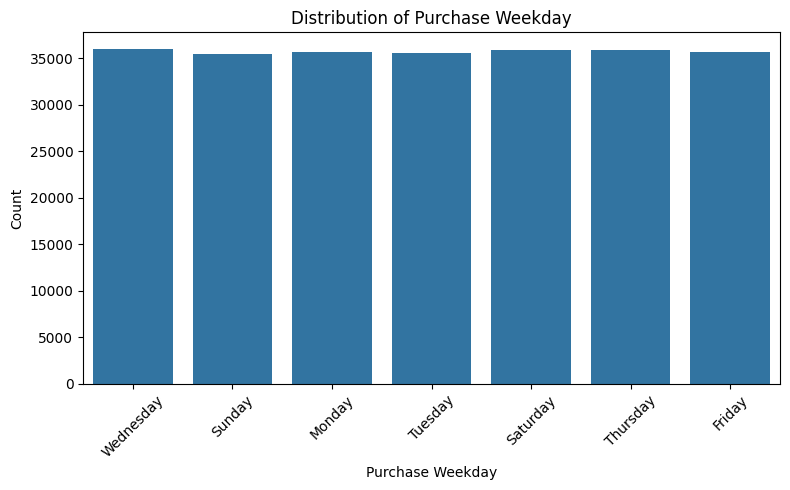

In [37]:
for col in categorical_columns:
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x=col)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n" * 3)

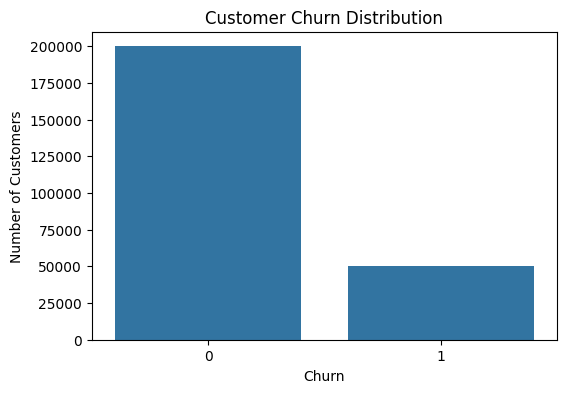

In [38]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')


plt.show()

### 2. Bivariate Analysis

## Age Distribution by Churn Status

This visualization compares the distribution of customer age across the two churn classes.

The purpose is to investigate whether customer age shows any noticeable difference between customers who churned and those who did not.


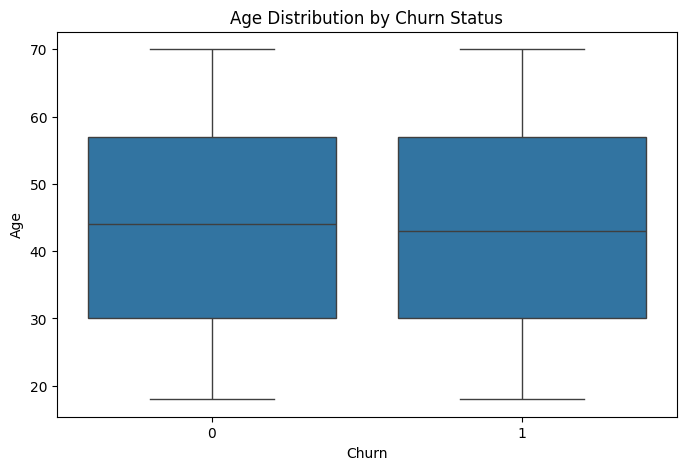

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='Age')

plt.title('Age Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Age')


plt.show()

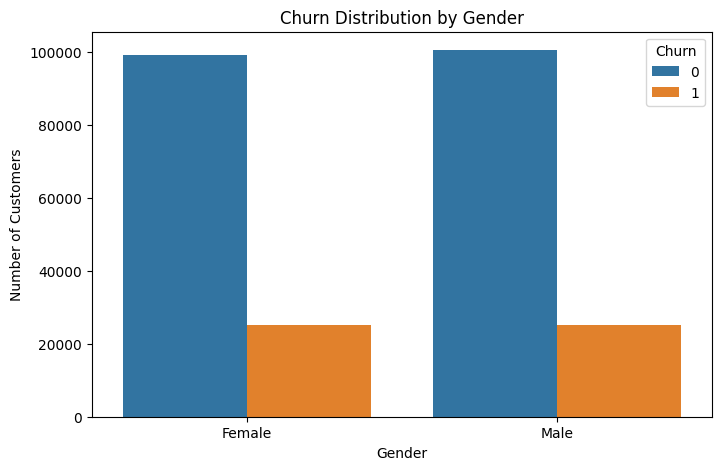

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Gender', hue='Churn')

plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')


plt.show()

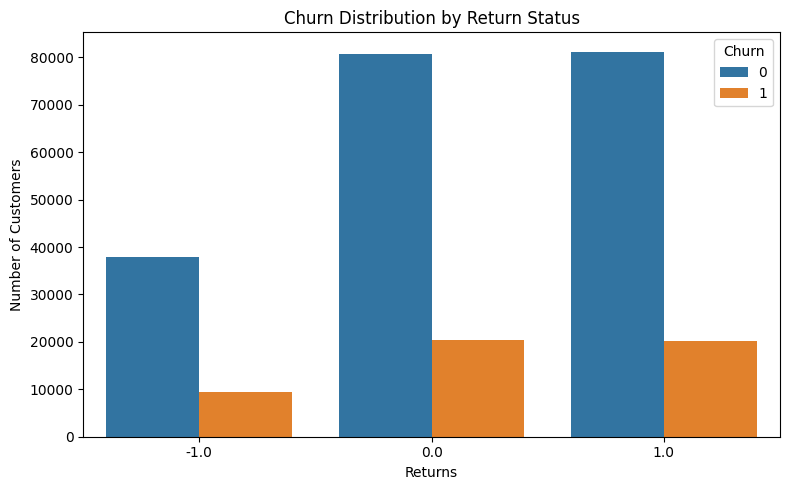

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Returns', hue='Churn')

plt.title('Churn Distribution by Return Status')
plt.xlabel('Returns')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Total Purchase Amount by Churn Status

This visualization compares the total purchase amount across the two churn classes.

It helps investigate whether spending behavior differs between customers who churned and customers who remained active.


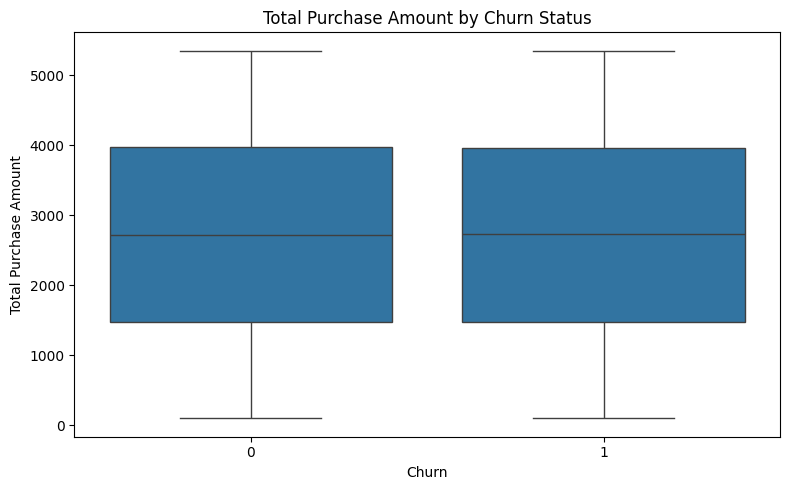

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='Total Purchase Amount')

plt.title('Total Purchase Amount by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Purchase Amount')

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

A correlation matrix is calculated for the numerical features to examine the strength and direction of relationships between them.

The correlation heatmap provides a visual representation of these relationships and helps identify highly correlated variables that may contain similar information.


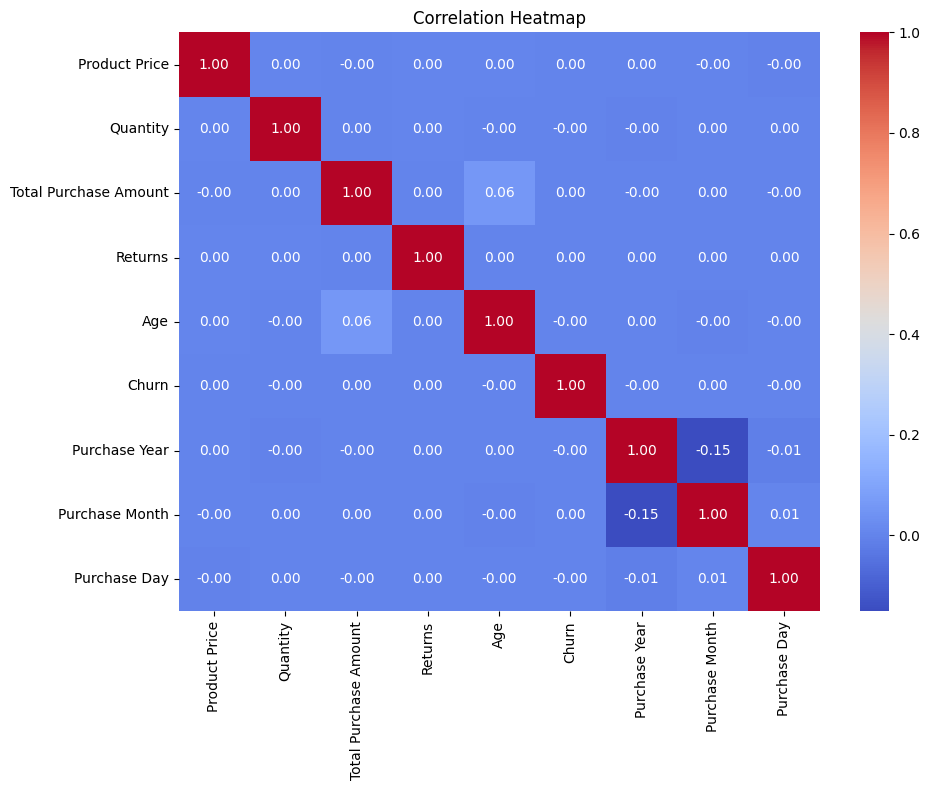

In [43]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Encoding Categorical Columns

Machine learning models work with numerical values, so categorical features need to be converted into a numerical representation before training.

In this step, the categorical columns are encoded so that their values can be processed by the machine learning algorithms.

This prepares the dataset for the preprocessing and model training stages.


In [44]:
import warnings
warnings.filterwarnings("ignore")

In [45]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = label.fit_transform(df[col])

# Feature & Target
Feature and Target Variables

In this step, the dataset is divided into feature variables (`X`) and the target variable (`y`).

The feature variables (`X`) contain the input variables that will be used by the machine learning models to make predictions.

The target variable (`y`) represents the outcome that the models aim to predict. In this project, `Churn` is used as the target variable.


In [46]:
x = df.drop(columns=['Churn'])
y = df['Churn']

#Train/Test Split

The dataset is divided into training and testing sets using `train_test_split`.

The test set represents 20% of the data, while the remaining 80% is used for training the machine learning models. A `random_state` of 42 is used to make the split reproducible.


In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

#Feature Scaling

Standardization is applied using `StandardScaler` to put the numerical features on a comparable scale.

The scaler is fitted on the training data and then applied to both the training and testing data. This ensures that the test data is transformed using the same scaling parameters learned from the training set.


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

# Save Scaler

The fitted `StandardScaler` is saved as `scaler.pkl` using `joblib`.

Saving the scaler allows the same preprocessing transformation to be reused later when making predictions on new data.


In [49]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Machine Learnimg Modeling

In this section, we define several classification models for predicting customer churn: Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), and Support Vector Classifier (SVC).

The SVC model is kept commented out because its training time is considerably longer with the large size of this dataset. Therefore, the other models are used for the main comparison.


The models will be trained and evaluated using the same training and testing data so that their performance can be compared using the same evaluation criteria.


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
   # 'SVC': SVC(probability=True)
}

# Train & Evaluate All Models

Each classification model is trained using the training data and then used to make predictions on the test data.

The performance of each model is evaluated using five metrics:

* Accuracy
* Precision
* Recall
* F1 Score
* ROC AUC Score

Using multiple evaluation metrics provides a more complete comparison of the classification models rather than relying on accuracy alone.


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results= []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        prec,
        rec,
        f1,
        roc
    ])

# Results Table
## Model Performance Comparison

The evaluation results from all trained models are combined into a single table.

This table makes it easier to compare the models across Accuracy, Precision, Recall, F1 Score, and ROC AUC Score and identify the model with the highest overall performance according to the selected metric.


In [52]:
results_df = pd.DataFrame(
    results,
    columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC AUC Score'
])

results_df.sort_values(
    'Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.80032,0.000000,0.000000,0.000000,0.494843
2,KNN,0.76520,0.200954,0.059095,0.091331,0.501553
1,Decision Tree,0.66292,0.199001,0.227464,0.212283,0.499515


# Best Model

The best-performing model is selected based on the highest Accuracy score.

The results table is sorted in descending order according to Accuracy, and the model in the first row is selected as the best model.


In [53]:
best_model_name = results_df.sort_values(
    'Accuracy',
    ascending=False
).iloc[0]['Model']

print(best_model_name)


Logistic Regression


# Neural Network

In this section, a Neural Network model is developed to predict customer churn.

The Neural Network is used as an additional approach to compare its performance with the traditional machine learning classification models used previously.


## Neural Network Libraries

TensorFlow and Keras are imported to build and train the Neural Network.

The model uses Dense layers along with Batch Normalization and Dropout. Early Stopping is also imported to help control the training process.


In [54]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping
)
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

## Build Neural Network

A Sequential Neural Network architecture is built using multiple fully connected Dense layers.

The network starts with 256 neurons and gradually reduces the number of neurons through layers with 128, 64, and 32 neurons. ReLU activation is used in the hidden layers, while a final single neuron with sigmoid activation is used for binary Churn classification.

Batch Normalization and Dropout layers are included to improve training stability and reduce overfitting.


In [55]:
model = Sequential()
model.add(Dense(
    256,
    activation="relu",
    input_shape=(x_train.shape[1],)
))


model.add(BatchNormalization())
model.add(Dropout(0.4))


model.add(Dense(
    128,
    activation="relu"
))


model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(
    64,
    activation="relu",
))


model.add(Dropout(0.25))


model.add(Dense(
    32,
    activation="relu"
))


model.add(Dense(
    1,
    activation="sigmoid"
))

## Compile the Neural Network

The Neural Network is compiled using the Adam optimizer and Binary Crossentropy loss function, which is suitable for binary classification.

Accuracy, Precision, and Recall are included as evaluation metrics to monitor the model's performance during training.


In [56]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 768 (3.00 KB)

## Early Stopping

Early Stopping is used to monitor the validation loss during training.

The model is allowed to continue training while the validation loss improves. A patience value of 15 is used to allow several epochs without improvement before stopping the training process.


In [58]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

## Train the Neural Network

The Neural Network is trained using the training data for up to 100 epochs with a batch size of 32.

A validation split of 20% is used during training to monitor the model's performance on unseen validation data. Early Stopping is applied to prevent unnecessary training when the validation loss stops improving.


In [59]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop,

    ],
    verbose=1
)

Epoch 1/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.7985 - loss: 0.5103 - precision: 0.1950 - recall: 9.6462e-04 - val_accuracy: 0.7998 - val_loss: 0.5045 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7991 - loss: 0.5038 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7998 - val_loss: 0.5025 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7991 - loss: 0.5028 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7998 - val_loss: 0.5016 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7991 - loss: 0.5023 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7998 - val_loss: 0.5014 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7991 - loss: 0

## Evaluate the Neural Network

The trained Neural Network is evaluated on the test set to measure its performance on data that was not used during training.

The evaluation reports Loss, Accuracy, Precision, and Recall, providing multiple measures of the model's predictive performance.


In [60]:
loss, accuracy, precision, recall = model.evaluate(
    x_test,
    y_test
)
print("Loss :", loss)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8003 - loss: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Loss : 0.49997419118881226
Accuracy : 0.800320029258728
Precision : 0.0
Recall : 0.0


# Final Conclusion

This project analyzed an e-commerce customer dataset and developed machine learning and Neural Network models to predict customer churn.

The data preprocessing stage included handling missing values, checking duplicates, converting date information, feature engineering, encoding categorical variables, and scaling the numerical features. Several classification models were then trained and evaluated using Accuracy, Precision, Recall, F1 Score, and ROC AUC.

Although some models achieved an Accuracy of approximately 80%, the additional evaluation metrics showed that Accuracy alone does not provide a reliable representation of the model's ability to identify churned customers. In particular, the low Precision, Recall, F1 Score, and ROC AUC values indicate limited ability to distinguish between the two Churn classes.

The dataset also shows a class imbalance, with the majority of customers belonging to the non-churn class. This helps explain why a model can achieve relatively high Accuracy while performing poorly at identifying the minority Churn class.

Overall, the project demonstrates the importance of using multiple evaluation metrics when working with imbalanced classification problems. The results also suggest that the available features may not contain enough information to effectively distinguish churned customers from non-churned customers. Additional customer behavior features or a more informative definition of the Churn target could potentially improve future versions of the model.
